In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Step 1.2 — Set Base Path & Add src/ to System Path**

In [2]:
import sys

BASE = '/content/drive/MyDrive/HousePricePrediction'
SRC  = f'{BASE}/src'

sys.path.append(SRC)

print(f"BASE path: {BASE}")
print(f"SRC  path: {SRC}")
print("Paths configured ✅")

BASE path: /content/drive/MyDrive/HousePricePrediction
SRC  path: /content/drive/MyDrive/HousePricePrediction/src
Paths configured ✅


# **Step 1.3 — Install & Import Libraries**

In [3]:
# No installs needed — all standard in Colab
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

# **Step 1.4 — Create data_loader.py in src/**

In [5]:
import os

data_loader_code = '''
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

def load_data():
    """Load California Housing dataset and return as DataFrame."""
    data = fetch_california_housing(as_frame=True)
    df = data.frame
    print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns ✅")
    return df

def get_basic_info(df):
    """Print basic dataset information."""
    print("\n--- Shape ---")
    print(df.shape)

    print("\n--- Columns ---")
    print(df.columns.tolist())

    print("\n--- Data Types ---")
    print(df.dtypes)

    print("\n--- Missing Values ---")
    print(df.isnull().sum())

    print("\n--- Basic Statistics ---")
    print(df.describe())

def get_feature_target_split(df):
    """Split dataframe into features and target."""
    X = df.drop('MedHouseVal', axis=1)
    y = df['MedHouseVal']
    print(f"Features: {X.shape[1]} columns ✅")
    print(f"Target  : MedHouseVal ✅")
    return X, y
'''

# Create the directory if it doesn't exist
os.makedirs(SRC, exist_ok=True)

# Write to Drive
with open(f'{SRC}/data_loader.py', 'w') as f:
    f.write(data_loader_code)

print("data_loader.py created in src/ ✅")

data_loader.py created in src/ ✅


# **Step 1.5 — Verify data_loader.py by Importing & Loading Data**

In [11]:
import os
import sys

SRC = '/content/drive/MyDrive/HousePricePrediction/src'

# Read the file content and execute it directly
with open(f'{SRC}/data_loader.py', 'r') as f:
    content = f.read()

print("File content preview:")
print(content[:100])
print("---")

exec(content)

# Now call the functions directly
df = load_data()
get_basic_info(df)

File content preview:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

def lo
---
Dataset loaded: 20640 rows, 9 columns
--- Shape ---
(20640, 9)
--- Columns ---
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
--- Data Types ---
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object
--- Missing Values ---
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
--- Basic Statistics ---
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425

# **STAGE 2 — Exploratory Data Analysis**

# **Step 2.1 — Target Variable Distribution**

outputs/ folder created ✅


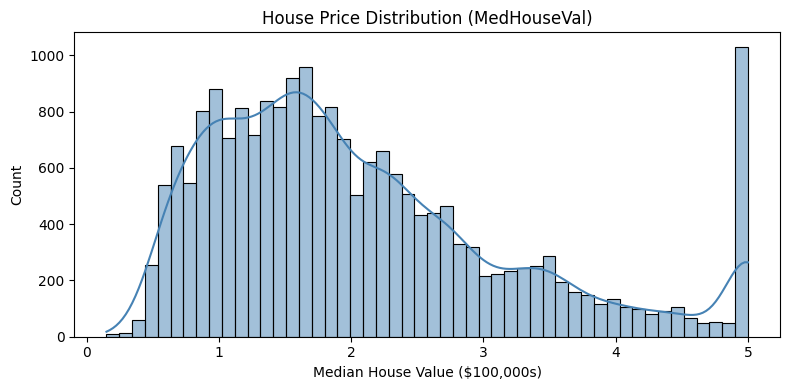

Plot saved to outputs/ ✅


In [13]:
import os

# Create outputs folder if it doesn't exist
os.makedirs(f'{BASE}/outputs', exist_ok=True)
print("outputs/ folder created ✅")

# Now save the plot
plt.figure(figsize=(8, 4))
sns.histplot(df['MedHouseVal'], bins=50, kde=True, color='steelblue')
plt.title("House Price Distribution (MedHouseVal)")
plt.xlabel("Median House Value ($100,000s)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/target_distribution.png', dpi=150)
plt.show()
print("Plot saved to outputs/ ✅")

# **Step 2.2 — Correlation Heatmap**

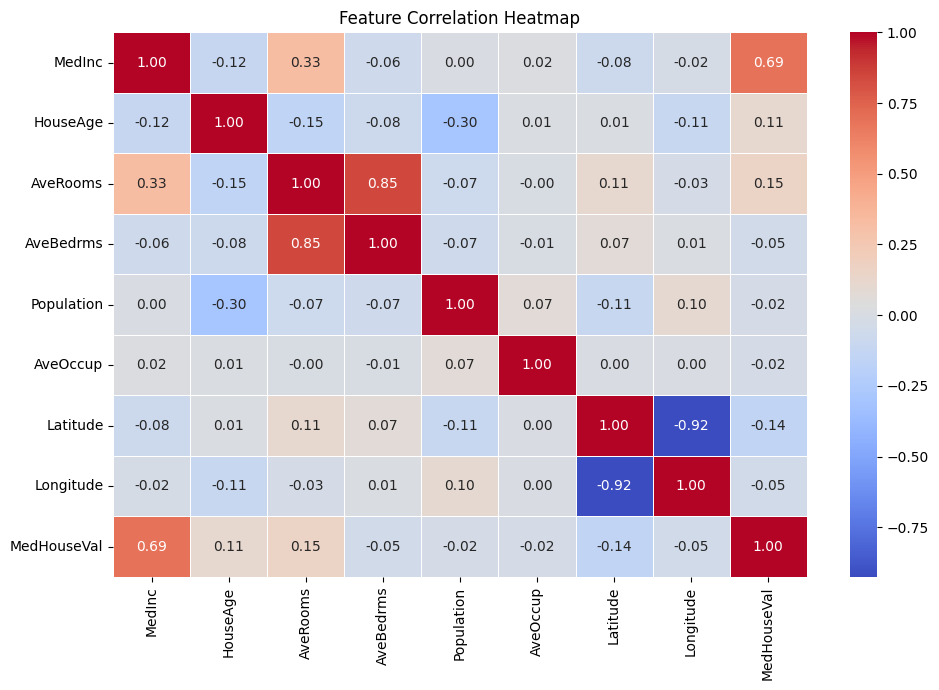

Correlation heatmap saved ✅


In [14]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/correlation_heatmap.png', dpi=150)
plt.show()
print("Correlation heatmap saved ✅")

# **Step 2.3 — Feature Distributions (All Features)**

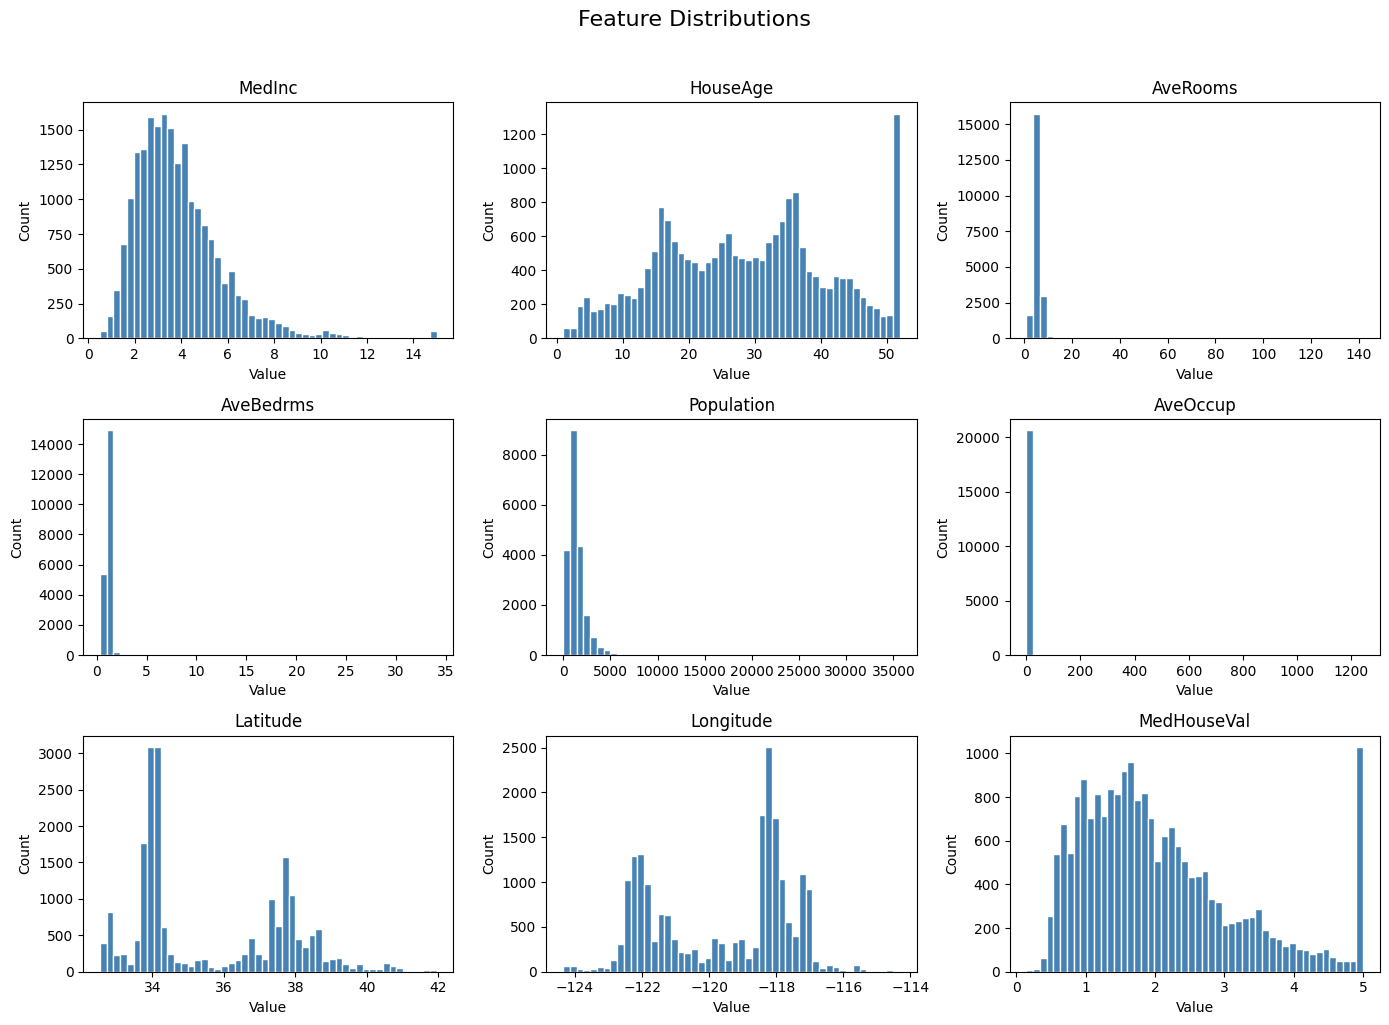

Feature distributions saved ✅


In [15]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle("Feature Distributions", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/feature_distributions.png', dpi=150)
plt.show()
print("Feature distributions saved ✅")

# **Step 2.4 — Outlier Detection (Boxplots)**

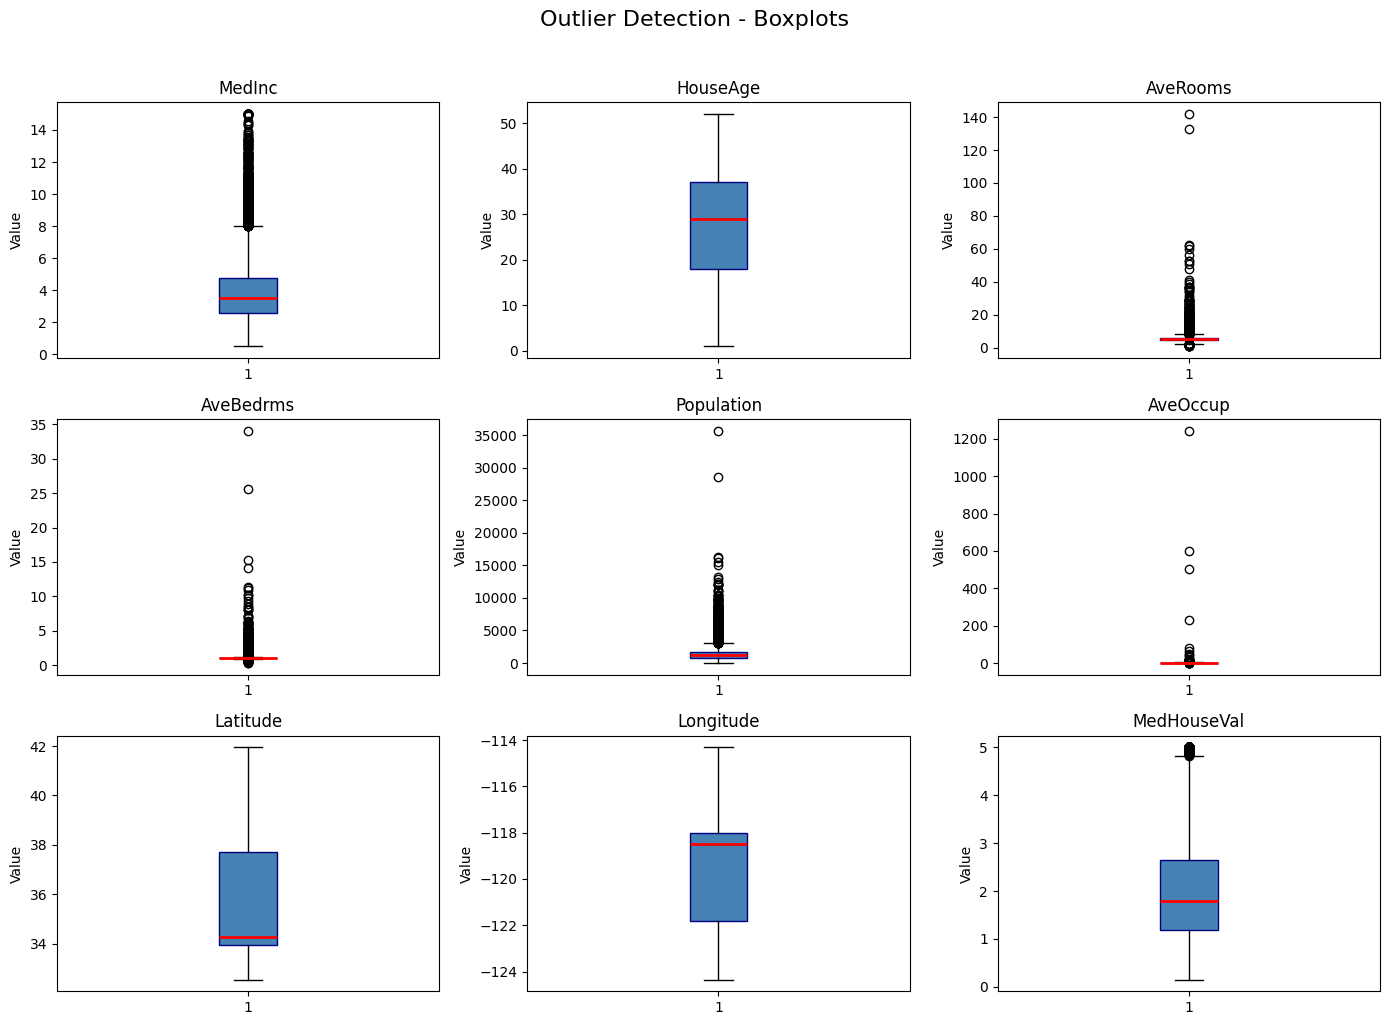

Outlier boxplots saved ✅


In [16]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle("Outlier Detection - Boxplots", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/outlier_boxplots.png', dpi=150)
plt.show()
print("Outlier boxplots saved ✅")

# **Step 2.5 — Geographic Price Distribution (Latitude vs Longitude)**

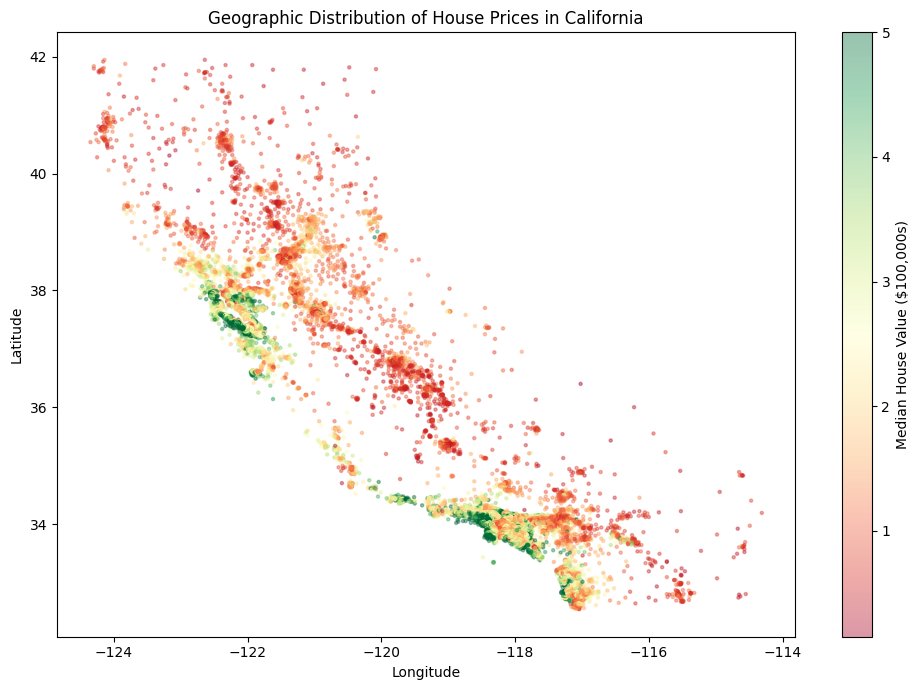

Geographic distribution saved ✅


In [17]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Longitude'], df['Latitude'],
                      c=df['MedHouseVal'], cmap='RdYlGn',
                      alpha=0.4, s=5)
plt.colorbar(scatter, label='Median House Value ($100,000s)')
plt.title("Geographic Distribution of House Prices in California")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/geographic_distribution.png', dpi=150)
plt.show()
print("Geographic distribution saved ✅")

# **Step 2.6 — MedInc vs House Price (Scatter)**

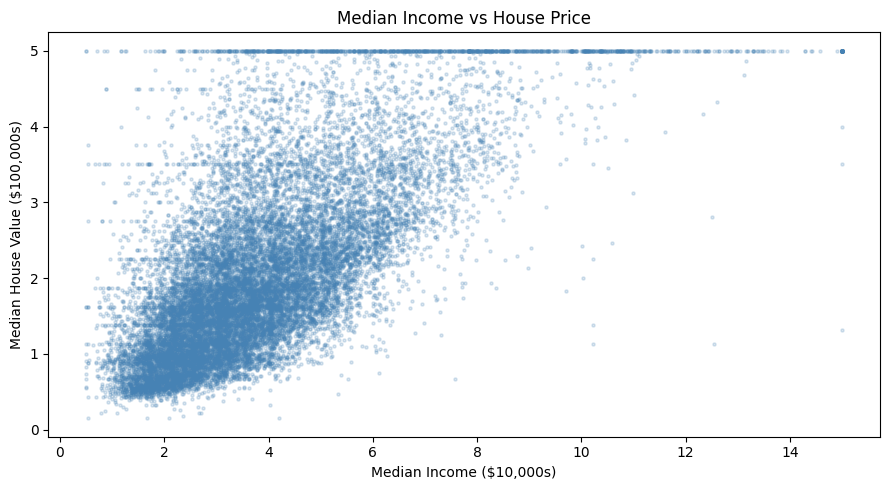

Income vs Price plot saved ✅


In [18]:
plt.figure(figsize=(9, 5))
plt.scatter(df['MedInc'], df['MedHouseVal'],
            alpha=0.2, color='steelblue', s=5)
plt.title("Median Income vs House Price")
plt.xlabel("Median Income ($10,000s)")
plt.ylabel("Median House Value ($100,000s)")
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/income_vs_price.png', dpi=150)
plt.show()
print("Income vs Price plot saved ✅")

# **Step 2.7 — Save EDA Summary to outputs/**

In [19]:
eda_summary = f"""
============================================================
         HOUSE PRICE PREDICTION — EDA SUMMARY
============================================================

DATASET
-------
Rows        : {df.shape[0]}
Columns     : {df.shape[1]}
Missing Val : {df.isnull().sum().sum()}

FEATURES
--------
{df.dtypes.to_string()}

TARGET VARIABLE (MedHouseVal)
-----------------------------
Min    : {df['MedHouseVal'].min():.4f}
Max    : {df['MedHouseVal'].max():.4f}
Mean   : {df['MedHouseVal'].mean():.4f}
Median : {df['MedHouseVal'].median():.4f}
Std    : {df['MedHouseVal'].std():.4f}

KEY OBSERVATIONS
----------------
1. Zero missing values — no imputation needed
2. MedInc is strongest predictor (corr ~0.69)
3. AveOccup, Population have extreme outliers (max 1243, 35682)
4. Price capped at 5.0 ($500k) — will affect high-end predictions
5. Coastal areas (LA, SF) clearly most expensive
6. AveRooms & AveBedrms are highly correlated — multicollinearity risk

NEXT STEP
---------
Feature Engineering — outlier capping, new features, scaling
============================================================
"""

with open(f'{BASE}/outputs/eda_summary.txt', 'w') as f:
    f.write(eda_summary)

print(eda_summary)
print("EDA summary saved to outputs/ ✅")


         HOUSE PRICE PREDICTION — EDA SUMMARY

DATASET
-------
Rows        : 20640
Columns     : 9
Missing Val : 0

FEATURES
--------
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64

TARGET VARIABLE (MedHouseVal)
-----------------------------
Min    : 0.1500
Max    : 5.0000
Mean   : 2.0686
Median : 1.7970
Std    : 1.1540

KEY OBSERVATIONS
----------------
1. Zero missing values — no imputation needed
2. MedInc is strongest predictor (corr ~0.69)
3. AveOccup, Population have extreme outliers (max 1243, 35682)
4. Price capped at 5.0 ($500k) — will affect high-end predictions
5. Coastal areas (LA, SF) clearly most expensive
6. AveRooms & AveBedrms are highly correlated — multicollinearity risk

NEXT STEP
---------
Feature Engineering — outlier capping, new features, scaling

EDA summary saved to outputs/ ✅


# **STAGE 3 — Feature Engineering**

# **Step 3.1 — Create feature_engineering.py in src/**

In [20]:
feature_engineering_code = """import pandas as pd
import numpy as np

def remove_outliers_iqr(df, columns, factor=1.5):
    df_clean = df.copy()
    removed = 0
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        before = len(df_clean)
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
        removed += before - len(df_clean)
    print(f"Rows removed as outliers : {removed}")
    print(f"Rows remaining           : {len(df_clean)}")
    return df_clean

def create_new_features(df):
    df = df.copy()
    df['RoomsPerHousehold']    = df['AveRooms']    / df['AveOccup']
    df['BedroomsPerRoom']      = df['AveBedrms']   / df['AveRooms']
    df['PopulationPerHousehold'] = df['Population'] / df['AveOccup']
    print("New features created:")
    print("  - RoomsPerHousehold")
    print("  - BedroomsPerRoom")
    print("  - PopulationPerHousehold")
    return df

def cap_price(df):
    before = len(df)
    df = df[df['MedHouseVal'] < 5.0].copy()
    removed = before - len(df)
    print(f"Price-capped rows removed : {removed}")
    print(f"Rows remaining            : {len(df)}")
    return df

def run_feature_engineering(df):
    print("--- Step 1: Remove price cap ---")
    df = cap_price(df)

    print("\\n--- Step 2: Remove outliers ---")
    outlier_cols = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
    df = remove_outliers_iqr(df, outlier_cols)

    print("\\n--- Step 3: Create new features ---")
    df = create_new_features(df)

    print(f"\\nFinal dataset shape: {df.shape}")
    print("Feature engineering complete ✅")
    return df
"""

with open(f'{SRC}/feature_engineering.py', 'w') as f:
    f.write(feature_engineering_code)

print("feature_engineering.py created in src/ ✅")

feature_engineering.py created in src/ ✅


# **Step 3.2 — Run Feature Engineering on Dataset**

In [21]:
# Read and execute feature_engineering.py
with open(f'{SRC}/feature_engineering.py', 'r') as f:
    exec(f.read())

# Run the full pipeline
df_engineered = run_feature_engineering(df)

# Preview result
print("\n--- Engineered Dataset Columns ---")
print(df_engineered.columns.tolist())

print("\n--- First 3 Rows ---")
print(df_engineered.head(3))

--- Step 1: Remove price cap ---
Price-capped rows removed : 992
Rows remaining            : 19648

--- Step 2: Remove outliers ---
Rows removed as outliers : 3108
Rows remaining           : 16540

--- Step 3: Create new features ---
New features created:
  - RoomsPerHousehold
  - BedroomsPerRoom
  - PopulationPerHousehold

Final dataset shape: (16540, 12)
Feature engineering complete ✅

--- Engineered Dataset Columns ---
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold']

--- First 3 Rows ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   

   Longitude  MedHouseVal  RoomsPerHousehold  BedroomsPerRoom  \
0 

# **Step 3.3 — Verify New Features Distribution**

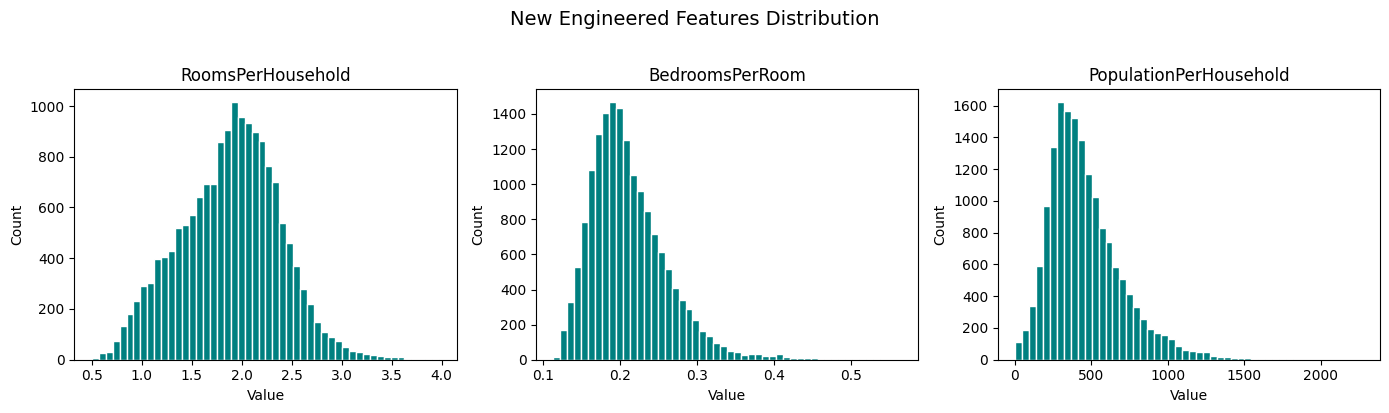

Engineered features distribution saved ✅


In [22]:
new_features = ['RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold']

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(new_features):
    axes[i].hist(df_engineered[col], bins=50, color='teal', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle("New Engineered Features Distribution", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f'{BASE}/outputs/engineered_features.png', dpi=150)
plt.show()
print("Engineered features distribution saved ✅")

# **Step 3.4 — Save Engineered Dataset & Feature Engineering Summary**

In [23]:
# Save engineered dataset as CSV to Drive
df_engineered.to_csv(f'{BASE}/outputs/engineered_dataset.csv', index=False)
print(f"Engineered dataset saved ✅")

# Save summary
fe_summary = f"""
============================================================
       HOUSE PRICE PREDICTION — FEATURE ENGINEERING SUMMARY
============================================================

ORIGINAL DATASET
----------------
Rows    : {df.shape[0]}
Columns : {df.shape[1]}

AFTER FEATURE ENGINEERING
--------------------------
Rows    : {df_engineered.shape[0]}
Columns : {df_engineered.shape[1]}
Removed : {df.shape[0] - df_engineered.shape[0]} rows

OPERATIONS PERFORMED
--------------------
1. Removed price-capped rows (MedHouseVal >= 5.0)
2. Removed outliers via IQR on:
   - AveRooms
   - AveBedrms
   - Population
   - AveOccup

NEW FEATURES CREATED
--------------------
1. RoomsPerHousehold      = AveRooms / AveOccup
2. BedroomsPerRoom        = AveBedrms / AveRooms
3. PopulationPerHousehold = Population / AveOccup

FINAL COLUMNS
-------------
{df_engineered.columns.tolist()}

NEXT STEP
---------
Model Training — Linear Regression, Random Forest, XGBoost
============================================================
"""

with open(f'{BASE}/outputs/feature_engineering_summary.txt', 'w') as f:
    f.write(fe_summary)

print(fe_summary)
print("Feature engineering summary saved ✅")

Engineered dataset saved ✅

       HOUSE PRICE PREDICTION — FEATURE ENGINEERING SUMMARY

ORIGINAL DATASET
----------------
Rows    : 20640
Columns : 9

AFTER FEATURE ENGINEERING
--------------------------
Rows    : 16540
Columns : 12
Removed : 4100 rows

OPERATIONS PERFORMED
--------------------
1. Removed price-capped rows (MedHouseVal >= 5.0)
2. Removed outliers via IQR on:
   - AveRooms
   - AveBedrms
   - Population
   - AveOccup

NEW FEATURES CREATED
--------------------
1. RoomsPerHousehold      = AveRooms / AveOccup
2. BedroomsPerRoom        = AveBedrms / AveRooms
3. PopulationPerHousehold = Population / AveOccup

FINAL COLUMNS
-------------
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal', 'RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold']

NEXT STEP
---------
Model Training — Linear Regression, Random Forest, XGBoost

Feature engineering summary saved ✅


# **STAGE 4 — Model Training**

In [24]:
train_code = """import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def prepare_data(df):
    X = df.drop('MedHouseVal', axis=1)
    y = df['MedHouseVal']
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)
    print(f"Train size : {X_train.shape[0]} rows")
    print(f"Test size  : {X_test.shape[0]} rows")
    print(f"Features   : {X_train.shape[1]} columns")
    print("Data prepared ✅")
    return X_train_scaled, X_test_scaled, y_train, y_test, scaler, X.columns.tolist()

def train_linear_regression(X_train, y_train):
    print("\\nTraining Linear Regression...")
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    scores = cross_val_score(lr, X_train, y_train, cv=5, scoring='r2')
    print(f"Cross-Val R² scores : {scores.round(4)}")
    print(f"Mean CV R²          : {scores.mean():.4f}")
    print("Linear Regression trained ✅")
    return lr

def train_random_forest(X_train, y_train):
    print("\\nTraining Random Forest...")
    rf = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='r2')
    print(f"Cross-Val R² scores : {scores.round(4)}")
    print(f"Mean CV R²          : {scores.mean():.4f}")
    print("Random Forest trained ✅")
    return rf

def train_xgboost(X_train, y_train):
    print("\\nTraining XGBoost...")
    xgb = XGBRegressor(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    scores = cross_val_score(xgb, X_train, y_train, cv=5, scoring='r2')
    print(f"Cross-Val R² scores : {scores.round(4)}")
    print(f"Mean CV R²          : {scores.mean():.4f}")
    print("XGBoost trained ✅")
    return xgb

def save_models(models_dict, scaler, models_dir):
    os.makedirs(models_dir, exist_ok=True)
    for name, model in models_dict.items():
        path = f"{models_dir}/{name}.joblib"
        joblib.dump(model, path)
        print(f"Saved {name} → {path}")
    joblib.dump(scaler, f"{models_dir}/scaler.joblib")
    print(f"Saved scaler → {models_dir}/scaler.joblib")
    print("All models saved ✅")
"""

with open(f'{SRC}/train.py', 'w') as f:
    f.write(train_code)

print("train.py created in src/ ✅")

train.py created in src/ ✅


# **Step 4.2 — Run Model Training**

In [25]:
# Read and execute train.py
with open(f'{SRC}/train.py', 'r') as f:
    exec(f.read())

# Prepare data
X_train, X_test, y_train, y_test, scaler, feature_names = prepare_data(df_engineered)

# Train all 3 models
lr  = train_linear_regression(X_train, y_train)
rf  = train_random_forest(X_train, y_train)
xgb = train_xgboost(X_train, y_train)

# Save all models and scaler to Drive
models_dict = {
    'linear_regression': lr,
    'random_forest'    : rf,
    'xgboost'          : xgb
}

save_models(models_dict, scaler, f'{BASE}/models')

Train size : 13232 rows
Test size  : 3308 rows
Features   : 11 columns
Data prepared ✅

Training Linear Regression...
Cross-Val R² scores : [0.6497 0.6629 0.6365 0.6777 0.6569]
Mean CV R²          : 0.6567
Linear Regression trained ✅

Training Random Forest...
Cross-Val R² scores : [0.7781 0.7786 0.7514 0.7825 0.7695]
Mean CV R²          : 0.7720
Random Forest trained ✅

Training XGBoost...
Cross-Val R² scores : [0.8258 0.8251 0.8139 0.8436 0.8196]
Mean CV R²          : 0.8256
XGBoost trained ✅
Saved linear_regression → /content/drive/MyDrive/HousePricePrediction/models/linear_regression.joblib
Saved random_forest → /content/drive/MyDrive/HousePricePrediction/models/random_forest.joblib
Saved xgboost → /content/drive/MyDrive/HousePricePrediction/models/xgboost.joblib
Saved scaler → /content/drive/MyDrive/HousePricePrediction/models/scaler.joblib
All models saved ✅


# **STAGE 5 — Model Evaluation**

In [26]:
evaluate_code = """import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test, name):
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"\\n--- {name} ---")
    print(f"MAE  : {mae:.4f}  (~${mae*100000:,.0f} average error)")
    print(f"RMSE : {rmse:.4f}  (~${rmse*100000:,.0f} root mean sq error)")
    print(f"R²   : {r2:.4f}")
    return preds, mae, rmse, r2

def plot_actual_vs_predicted(y_test, preds, name, save_path):
    plt.figure(figsize=(8, 5))
    plt.scatter(y_test, preds, alpha=0.3, color='teal', s=5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', linewidth=2, label='Perfect Fit')
    plt.xlabel("Actual Price ($100,000s)")
    plt.ylabel("Predicted Price ($100,000s)")
    plt.title(f"{name}: Actual vs Predicted")
    plt.legend()
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path} ✅")

def plot_residuals(y_test, preds, name, save_path):
    residuals = y_test - preds
    plt.figure(figsize=(8, 5))
    plt.scatter(preds, residuals, alpha=0.3, color='steelblue', s=5)
    plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
    plt.xlabel("Predicted Price ($100,000s)")
    plt.ylabel("Residuals")
    plt.title(f"{name}: Residual Plot")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path} ✅")

def plot_feature_importance(model, feature_names, save_path):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances.sort_values().plot(kind='barh', figsize=(9, 6), color='steelblue')
    plt.title("Feature Importance (XGBoost)")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path} ✅")

def plot_model_comparison(results_dict, save_path):
    names  = list(results_dict.keys())
    maes   = [results_dict[n]['mae']  for n in names]
    rmses  = [results_dict[n]['rmse'] for n in names]
    r2s    = [results_dict[n]['r2']   for n in names]

    x = range(len(names))
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))

    axes[0].bar(names, maes,  color='steelblue')
    axes[0].set_title("MAE (lower is better)")
    axes[0].set_ylabel("MAE")

    axes[1].bar(names, rmses, color='teal')
    axes[1].set_title("RMSE (lower is better)")
    axes[1].set_ylabel("RMSE")

    axes[2].bar(names, r2s,   color='seagreen')
    axes[2].set_title("R² Score (higher is better)")
    axes[2].set_ylabel("R²")

    for ax in axes:
        ax.set_xticks(range(len(names)))
        ax.set_xticklabels(names, rotation=15)

    plt.suptitle("Model Comparison", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved → {save_path} ✅")
"""

with open(f'{SRC}/evaluate.py', 'w') as f:
    f.write(evaluate_code)

print("evaluate.py created in src/ ✅")

evaluate.py created in src/ ✅


# **Step 5.2 — Run Full Evaluation on All 3 Moels**

In [27]:
# Read and execute evaluate.py
with open(f'{SRC}/evaluate.py', 'r') as f:
    exec(f.read())

# Evaluate all 3 models
results = {}

for name, model in [('Linear Regression', lr), ('Random Forest', rf), ('XGBoost', xgb)]:
    preds, mae, rmse, r2 = evaluate_model(model, X_test, y_test, name)
    results[name] = {'mae': mae, 'rmse': rmse, 'r2': r2, 'preds': preds}

print("\n--- Evaluation Complete ✅ ---")


--- Linear Regression ---
MAE  : 0.4149  (~$41,487 average error)
RMSE : 0.5613  (~$56,132 root mean sq error)
R²   : 0.6697

--- Random Forest ---
MAE  : 0.3023  (~$30,226 average error)
RMSE : 0.4433  (~$44,326 root mean sq error)
R²   : 0.7940

--- XGBoost ---
MAE  : 0.2680  (~$26,801 average error)
RMSE : 0.3938  (~$39,385 root mean sq error)
R²   : 0.8374

--- Evaluation Complete ✅ ---


# **Step 5.4 — Plot Feature Importance & Model Comparison**

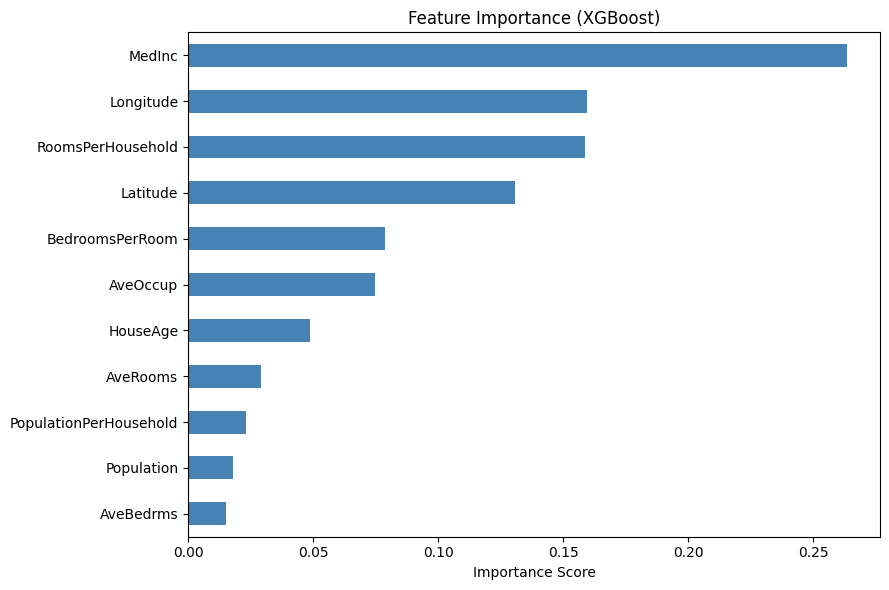

Saved → /content/drive/MyDrive/HousePricePrediction/outputs/feature_importance_xgboost.png ✅


In [28]:
# Feature Importance — XGBoost
plot_feature_importance(
    xgb,
    feature_names,
    f'{BASE}/outputs/feature_importance_xgboost.png'
)

# **Step 5.5 — Plot Model Comparison**

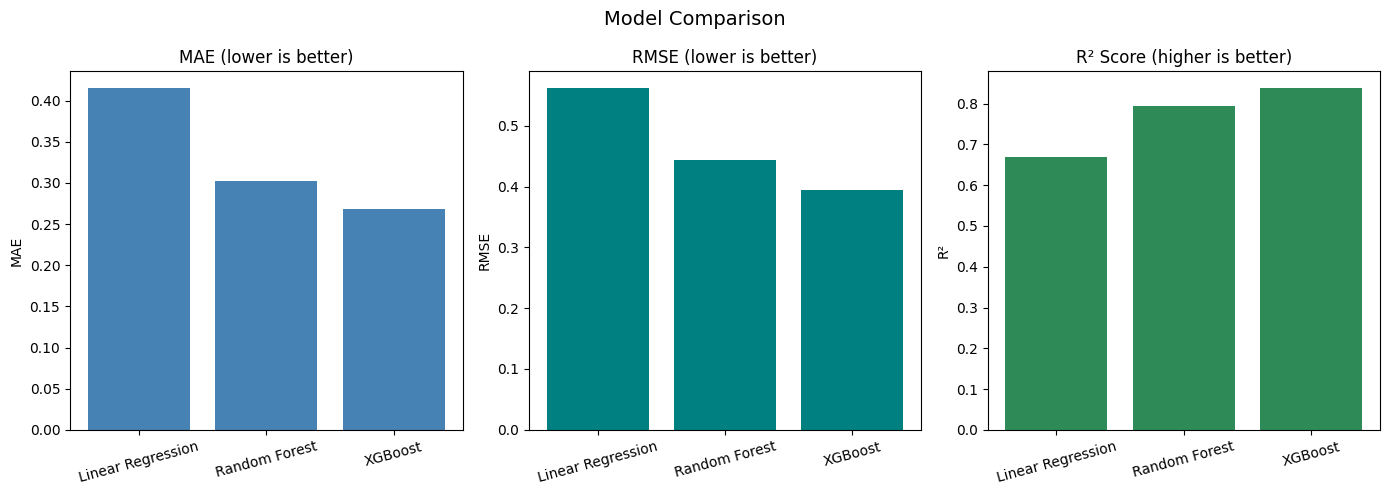

Saved → /content/drive/MyDrive/HousePricePrediction/outputs/model_comparison.png ✅


In [29]:
# Remove preds key before passing to plot function
comparison = {
    'Linear Regression': {'mae': results['Linear Regression']['mae'],
                          'rmse': results['Linear Regression']['rmse'],
                          'r2': results['Linear Regression']['r2']},
    'Random Forest'    : {'mae': results['Random Forest']['mae'],
                          'rmse': results['Random Forest']['rmse'],
                          'r2': results['Random Forest']['r2']},
    'XGBoost'          : {'mae': results['XGBoost']['mae'],
                          'rmse': results['XGBoost']['rmse'],
                          'r2': results['XGBoost']['r2']}
}

plot_model_comparison(comparison, f'{BASE}/outputs/model_comparison.png')

# Step 5.6 — Save Final Metrics **Report**

In [30]:
metrics_report = f"""
============================================================
      HOUSE PRICE PREDICTION — FINAL METRICS REPORT
============================================================

TEST SET RESULTS
----------------

Linear Regression
  MAE  : 0.4149  (~$41,487 average error)
  RMSE : 0.5613  (~$56,132 root mean sq error)
  R²   : 0.6697

Random Forest
  MAE  : 0.3023  (~$30,226 average error)
  RMSE : 0.4433  (~$44,326 root mean sq error)
  R²   : 0.7940

XGBoost ✅ BEST MODEL
  MAE  : 0.2680  (~$26,801 average error)
  RMSE : 0.3938  (~$39,385 root mean sq error)
  R²   : 0.8374

CROSS-VALIDATION R² (5-Fold)
-----------------------------
  Linear Regression : 0.6567
  Random Forest     : 0.7720
  XGBoost           : 0.8256

CONCLUSION
----------
XGBoost is selected as the final production model.
- Best R² of 0.8374 on test set
- Lowest MAE of $26,801
- Consistent CV scores confirm no overfitting
- MedInc confirmed as strongest predictor
- Price cap at $500k introduces unavoidable error at higher end

============================================================
"""

with open(f'{BASE}/outputs/metrics_report.txt', 'w') as f:
    f.write(metrics_report)

print(metrics_report)
print("Metrics report saved to outputs/ ✅")


      HOUSE PRICE PREDICTION — FINAL METRICS REPORT

TEST SET RESULTS
----------------

Linear Regression
  MAE  : 0.4149  (~$41,487 average error)
  RMSE : 0.5613  (~$56,132 root mean sq error)
  R²   : 0.6697

Random Forest
  MAE  : 0.3023  (~$30,226 average error)
  RMSE : 0.4433  (~$44,326 root mean sq error)
  R²   : 0.7940

XGBoost ✅ BEST MODEL
  MAE  : 0.2680  (~$26,801 average error)
  RMSE : 0.3938  (~$39,385 root mean sq error)
  R²   : 0.8374

CROSS-VALIDATION R² (5-Fold)
-----------------------------
  Linear Regression : 0.6567
  Random Forest     : 0.7720
  XGBoost           : 0.8256

CONCLUSION
----------
XGBoost is selected as the final production model.
- Best R² of 0.8374 on test set
- Lowest MAE of $26,801
- Consistent CV scores confirm no overfitting
- MedInc confirmed as strongest predictor
- Price cap at $500k introduces unavoidable error at higher end


Metrics report saved to outputs/ ✅


# **STAGE 6 — Prediction Pipeline**

In [31]:
predict_code = """import pandas as pd
import numpy as np
import joblib

def load_model_and_scaler(models_dir):
    model  = joblib.load(f"{models_dir}/xgboost.joblib")
    scaler = joblib.load(f"{models_dir}/scaler.joblib")
    print("Model and scaler loaded ✅")
    return model, scaler

def predict_price(model, scaler, input_dict):
    expected_cols = [
        'MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
        'Population', 'AveOccup', 'Latitude', 'Longitude',
        'RoomsPerHousehold', 'BedroomsPerRoom', 'PopulationPerHousehold'
    ]

    input_df = pd.DataFrame([input_dict])

    # Auto-calculate engineered features if not provided
    if 'RoomsPerHousehold' not in input_df.columns:
        input_df['RoomsPerHousehold']      = input_df['AveRooms']    / input_df['AveOccup']
        input_df['BedroomsPerRoom']        = input_df['AveBedrms']   / input_df['AveRooms']
        input_df['PopulationPerHousehold'] = input_df['Population']  / input_df['AveOccup']

    input_df = input_df[expected_cols]
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)[0]
    price_dollars = prediction * 100000

    print(f"\\n--- Prediction Result ---")
    print(f"Predicted Value  : {prediction:.4f} (x$100,000)")
    print(f"Estimated Price  : ${price_dollars:,.0f}")
    return prediction, price_dollars

def validate_input(input_dict):
    required = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
                'Population', 'AveOccup', 'Latitude', 'Longitude']
    missing = [k for k in required if k not in input_dict]
    if missing:
        raise ValueError(f"Missing required fields: {missing}")
    if input_dict['AveRooms'] <= 0:
        raise ValueError("AveRooms must be greater than 0")
    if input_dict['AveOccup'] <= 0:
        raise ValueError("AveOccup must be greater than 0")
    if not (-124.5 <= input_dict['Longitude'] <= -114.0):
        raise ValueError("Longitude out of California range")
    if not (32.5 <= input_dict['Latitude'] <= 42.0):
        raise ValueError("Latitude out of California range")
    print("Input validation passed ✅")
"""

with open(f'{SRC}/predict.py', 'w') as f:
    f.write(predict_code)

print("predict.py created in src/ ✅")

predict.py created in src/ ✅


# **Step 6.2 — Test the Prediction Pipeline**

In [32]:
# Read and execute predict.py
with open(f'{SRC}/predict.py', 'r') as f:
    exec(f.read())

# Load saved XGBoost model and scaler from Drive
model, scaler = load_model_and_scaler(f'{BASE}/models')

# Test with a sample house
sample_house = {
    'MedInc'    : 5.0,
    'HouseAge'  : 20.0,
    'AveRooms'  : 6.0,
    'AveBedrms' : 1.2,
    'Population': 500.0,
    'AveOccup'  : 3.0,
    'Latitude'  : 34.05,
    'Longitude' : -118.25
}

# Validate then predict
validate_input(sample_house)
prediction, price_dollars = predict_price(model, scaler, sample_house)

Model and scaler loaded ✅
Input validation passed ✅

--- Prediction Result ---
Predicted Value  : 2.3554 (x$100,000)
Estimated Price  : $235,543
